# import

### Picture for signal noise

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../General_Functions/")
from BasicData import *
from Flow_functions import * # import flow functions, Information to the agent
from Geometric_functions import * # Import rotation from euler angles
from Evolution_Traj import * # Import time integration for trjectories
from Time_Int_Traj import * # Import evolution function
from BasicData import *  # Nagents, R0, V
from Strategies import * # Import strategies, Braitenberg or Triangulation
from Flow_functions import * # Import flow functions: stokeslet, grads, strains ... 


In [8]:
# Sign function
def calculate_S(n, v0, v1, v2):
    """
    Calculate S = (n·v2)||v0||^2 - (n·v0)(v0·v2)
    """
    n_dot_v2 = np.dot(n, v2)
    n_dot_v0 = np.dot(n, v0)
    v0_dot_v2 = np.dot(v0, v2)
    v0_norm_squared = np.dot(v0, v0)
    return n_dot_v2 * v0_norm_squared - n_dot_v0 * v0_dot_v2

# --- Usage ---

# --- Parameters ---
NPoints = 80
NTrials = 100
AntennaeLength = 0.01
NoiseLevels = np.array([0.01, 1.0, 10.0, 100.0]) * AntennaeLength**2
x = np.linspace(.1, 5, NPoints)
z = np.linspace(.1, 5, NPoints)
e3 = np.array([1, 0, 0])
Grads = [GradientStresslet]  # Make sure this is defined

NameStrategies = ["T"]

In [9]:

def Evolution(Grad, NoiseIntensity):

    # Function to evaluate the scalar product between t at the end of the evolution
    t0_T, t1_T, t2_T = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
    DotProduct_T = np.zeros((NPoints, NPoints, NTrials))
    # DotProduct_I = np.zeros((NPoints, NPoints, NTrials))

    for k in range(NPoints):
        for i in range(NPoints):
            # Position the agent 
            AgentPosition =  np.array([z[k], x[i], 0.])

            # Source position
            OptimalDirection = -AgentPosition/np.linalg.norm(AgentPosition)

            for trials_i in range(NTrials):
                # Random orientation of agent axis
                alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
                R = Rotation(alpha, np.abs(beta), gamma)
                n = np.dot(R, [0, 1, 0])

                xs1 = AgentPosition + AntennaeLength * n
                xs2 = AgentPosition - AntennaeLength * n

                v0 = np.dot(Grad(e3, AgentPosition), n)
                v1 = np.dot(Grad(e3, xs1), n)
                v2 = np.dot(Grad(e3, xs2), n)
                #SignalWithoutNoise = calculate_S(n, v0, v1, v2)
                
                SignalWithNoise = calculate_S(n, v0, v1, v2) + np.random.normal(0, NoiseIntensity)
                t_T = np.dot(Grad(e3, AgentPosition), n)*SignalWithNoise
                t_T /= np.linalg.norm(t_T)
                # t0_T_not[k, i, trials_i], t1_T_not[k, i, trials_i], t2_T_not[k, i, trials_i] = t_T_not
                t0_T[k, i, trials_i], t1_T[k, i, trials_i], t2_T[k, i, trials_i] = t_T
                # t0_I[k, i, trials_i], t1_I[k, i, trials_i], t2_I[k, i, trials_i] = t_I

                # Dot product Evaluation
                # DotProduct_T_not[k, i, trials_i] = np.dot(t_T_not, OptimalDirection)
                DotProduct_T[k, i, trials_i] = np.dot(t_T, OptimalDirection)
                # DotProduct_I[k, i, trials_i] = np.dot(t_I, OptimalDirection)


    return DotProduct_T, \
        t0_T, t1_T#,\
        #t0_T_not, t1_T_not,\
        #t0_I, t1_I, DotProduct_T_not, DotProduct_I,


In [10]:
for Intensity in NoiseLevels:
    for grads_i, Grad in enumerate(Grads):
        # t axis for Triangulation strategy absence of roll
        t0_T, t1_T = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
    
        # Evaluate the strategy 2D map, vector P 
        Avg_P_T = np.zeros((NPoints, NPoints, NTrials))
    
        # Call Evaluation function and evaluate 
        Avg_P_T, t0_T, t1_T = Evolution(Grad, Intensity)
        
        # Save data
    
        AllAvg = [Avg_P_T] #, Avg_P_T, Avg_P_I]
        Allt0 = [t0_T] # _not, t0_T, t0_I]
        Allt1 = [t1_T] # _not, t1_T, t1_I]
    
        for i, strat_name in enumerate(NameStrategies):
            np.savetxt(f"Data_SignalNoiseTests/{GradName[grads_i]}_Avg_{strat_name}_Intensity_{Intensity:.1e}.txt", np.mean(AllAvg[i], axis = 2), delimiter = ',')
            np.savetxt(f"Data_SignalNoiseTests/{GradName[grads_i]}_t0_{strat_name}_Intensity_{Intensity:.1e}.txt", np.mean(Allt0[i], axis = 2), delimiter = ',')
            np.savetxt(f"Data_SignalNoiseTests/{GradName[grads_i]}_t1_{strat_name}_Intensity_{Intensity:.1e}.txt", np.mean(Allt1[i], axis = 2), delimiter = ',')

#plt.show()


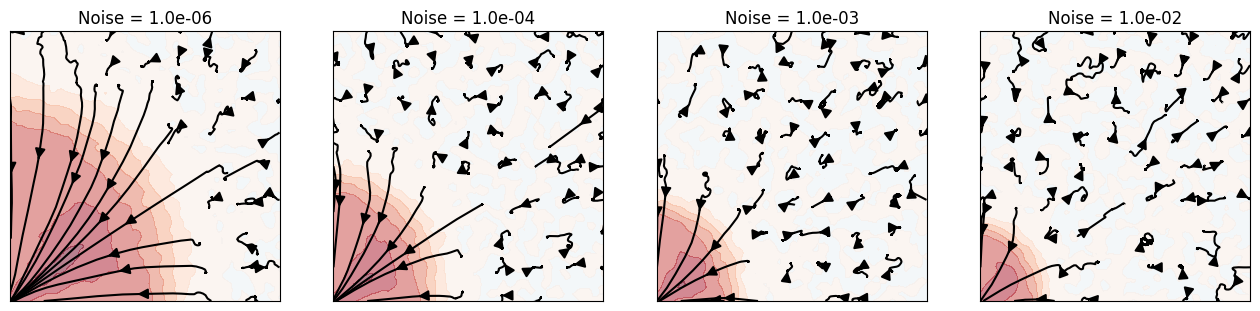

In [11]:

import scipy.ndimage as ndimage # import to smooth plots
n_levels = len(NoiseLevels)
fig, axes = plt.subplots(1, n_levels, figsize=(4*n_levels, 5), sharex=True, sharey=True)
X, Z = np.meshgrid(x, z, indexing='xy')

# Plot parameters
CMAP = 'RdBu_r' #'spring'
STREAMCOLOR = 'black'
MIN_VALUE = -1
MAX_VALUE = 1

for grads_i, Grad in enumerate(GradName):
    for i, strat_name in enumerate(NameStrategies):
        for idx, Intensity in enumerate(NoiseLevels):
            # Extract data from saved file
            with open(f"Data_SignalNoiseTests/{GradName[grads_i]}_Avg_{strat_name}_Intensity_{Intensity:.1e}.txt", 'r') as the_file:
                Avg = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 
    
            with open(f"Data_SignalNoiseTests/{GradName[grads_i]}_t0_{strat_name}_Intensity_{Intensity:.1e}.txt", 'r') as the_file:
    
                t0 = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 
            with open(f"Data_SignalNoiseTests/{GradName[grads_i]}_t1_{strat_name}_Intensity_{Intensity:.1e}.txt", 'r') as the_file:
    
                t1 = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 

            if len(NoiseLevels) > 1:
                ax = axes[idx]
                ax.set_title(f'Noise = {Intensity:.1e}')
            else:
                ax = axes
                ax.set_title(f'Signal Intensity')
            
            Avg = ndimage.gaussian_filter(Avg, sigma=1.0, order=0)
            im = ax.contourf(X, Z, Avg, cmap = CMAP,  vmin= MIN_VALUE, vmax = MAX_VALUE, alpha = 0.5)
            ax.streamplot(X, Z, t1, t0, color = STREAMCOLOR,  density = .3,  arrowsize = 1.5, broken_streamlines=False)
            #PlotCircles(ax1, .5)
            ax.set_xlim([.1, 5])
            ax.set_ylim([.1, 5])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect('equal', 'box')
plt.savefig('./Plot_SignalNoiseTests/Map_distinct_noise_levels.png')

# Radial, test theory prediction 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

def calculate_S(n, v0, v1, v2):
    """
    Calculate S = (n·v2)||v0||^2 - (n·v0)(v0·v2)
    """
    n_dot_v2 = np.dot(n, v2)
    n_dot_v0 = np.dot(n, v0)
    v0_dot_v2 = np.dot(v0, v2)
    v0_norm_squared = np.dot(v0, v0)
    return n_dot_v2 * v0_norm_squared - n_dot_v0 * v0_dot_v2

def PlotSignalAlongRadius(r, NTrials, Grad, e3, AntennaeLength, NoiseIntensity):
    NPoints = len(r)
    SignalSign = np.zeros((NPoints, NTrials))
    SignalVector = np.zeros((NPoints, NTrials))
    
    for i in range(NPoints):
            AgentPosition = np.array([r[i], r[i], 0.])
            AgentNorm = np.linalg.norm(AgentPosition)
            if AgentNorm == 0:
                continue
            OptimalDirection = -AgentPosition / AgentNorm

            for trials_i in range(NTrials):
                alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
                R = Rotation(alpha, np.abs(beta), gamma)
                n = np.dot(R, [0, 1, 0])

                xs1 = AgentPosition + AntennaeLength * n
                xs2 = AgentPosition - AntennaeLength * n

                v0 = np.dot(Grad(e3, AgentPosition), n)
                v1 = np.dot(Grad(e3, xs1), n)
                v2 = np.dot(Grad(e3, xs2), n)
                SignalWithoutNoise = calculate_S(n, v0, v1, v2)
                SignalWithNoise = SignalWithoutNoise + np.random.normal(0, NoiseIntensity)
                
                if np.sign(SignalWithoutNoise * SignalWithNoise) > 0:
                    SignalSign[i, trials_i] += 1.0
                    SignalVector[i, trials_i] += abs(SignalWithoutNoise)

    return SignalSign, SignalVector

# --- Usage ---

# --- Parameters ---
NPoints = 300
NTrials = 200
AntennaeLength = 0.001
NoiseLevels = np.array([0.0, 1.0, 10.0, 100.0]) * AntennaeLength**2
r = np.linspace(1, 5, NPoints)
e3 = np.array([1, 0, 0])
Grads = [GradientStokeslet]  # Make sure this is defined

# --- Plotting ---
n_levels = len(NoiseLevels)
fig, axes = plt.subplots(1, n_levels, figsize=(4*n_levels, 5), sharex=True, sharey=True)

for idx, noise in enumerate(NoiseLevels):
    if len(NoiseLevels) > 1:
        ax = axes[idx]
        ax.set_title(f'Noise = {noise:.1e}')
    else:
        ax = axes
        ax.set_title(f'Signal Intensity')
        
    SignalSign, SignalsVector = PlotSignalAlongRadius(r, NTrials, Grads[0], e3, AntennaeLength, noise)
    AvgSignalsVector = np.mean(SignalsVector, axis=1)
    AvgSignalSign = np.mean(SignalSign, axis=1)
    
    # Calculate probability of changing sign
    
    # Compute the CDF using the formula
    std_noise = noise  # Standard deviation of noise, you can adjust if needed
    f_r = AvgSignalsVector  # Signal values along radius

    CDF = 0.5 * (1 + erf(f_r /(np.sqrt(2)* std_noise)))
    
    # Plot both the sign change probability and CDF
    ax.plot(r, AvgSignalSign, label='Probability of Sign ')
    ax.plot(r, CDF, label='CDF', linestyle='--')
    
    ax.set_xlim([1, np.max(r)])
    ax.set_ylim([0, 1.1])
    ax.set_xlabel('r (Radius)')
    if idx == 0:
        ax.set_ylabel('Probability / CDF')
    ax.grid(True)
    ax.legend()


plt.tight_layout(rect=[0, 0, 0.88, 1])  # Leave room for colorbar

plt.savefig(f"Plots_SignalNoiseTests/NoiseSensorySignRadial.png", bbox_inches='tight')
plt.show()
